# **Explainable Wrist Fracture Model from X-rays images**

## Import Libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import sklearn as sl
import tensorflow as tf

## Load Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tommyngx/mura-v1")

print("Path to dataset files:", path)

100%|██████████| 3.14G/3.14G [00:32<00:00, 103MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tommyngx/mura-v1/versions/1


## Get path of images by csv file

In [ ]:
train_df = pd.read_csv(os.path.join(path, "MURA-v1.1/train_image_paths.csv"), header = None )
val_df = pd.read_csv(os.path.join(path, "MURA-v1.1/valid_image_paths.csv"),  header = None)

## Shape of train & valid dataset

In [ ]:
train_df.shape
val_df.shape

(3197, 1)

## Create training and validation arrays

In [ ]:
train_imgs = []
train_labels = []
val_imgs = []
val_labels = []
for i in range(len(train_df)):
  train_image_path =  os.path.join(path, train_df[0][i])
  train_imgs.append(train_image_path)
  train_labels.append("Fracture" if "positive" in train_image_path else "Normal")
for i in range(len(val_df)):
  val_image_path =  os.path.join(path, val_df[0][i])
  val_imgs.append(val_image_path)
  val_labels.append("Fracture" if "positive" in val_image_path else "Normal")

## Lengths of arrays

In [ ]:
print("Total training images",len(train_imgs))
print("Total training labels",len(train_labels))
print("Total val images",len(val_imgs))
print("Total val labels",len(val_labels))
print("Total images are", len(train_imgs)+len(val_imgs))

Total training images 36808
Total training labels 36808
Total val images 3197
Total val labels 3197
Total images are 40005


## Visualize the image

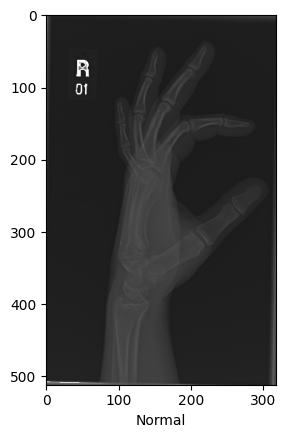

In [ ]:
num = random.randint(0,36000)
img = cv2.imread(train_imgs[num])
plt.imshow(img, cmap='gray')
plt.xlabel(train_labels[num])
plt.show()

## See images

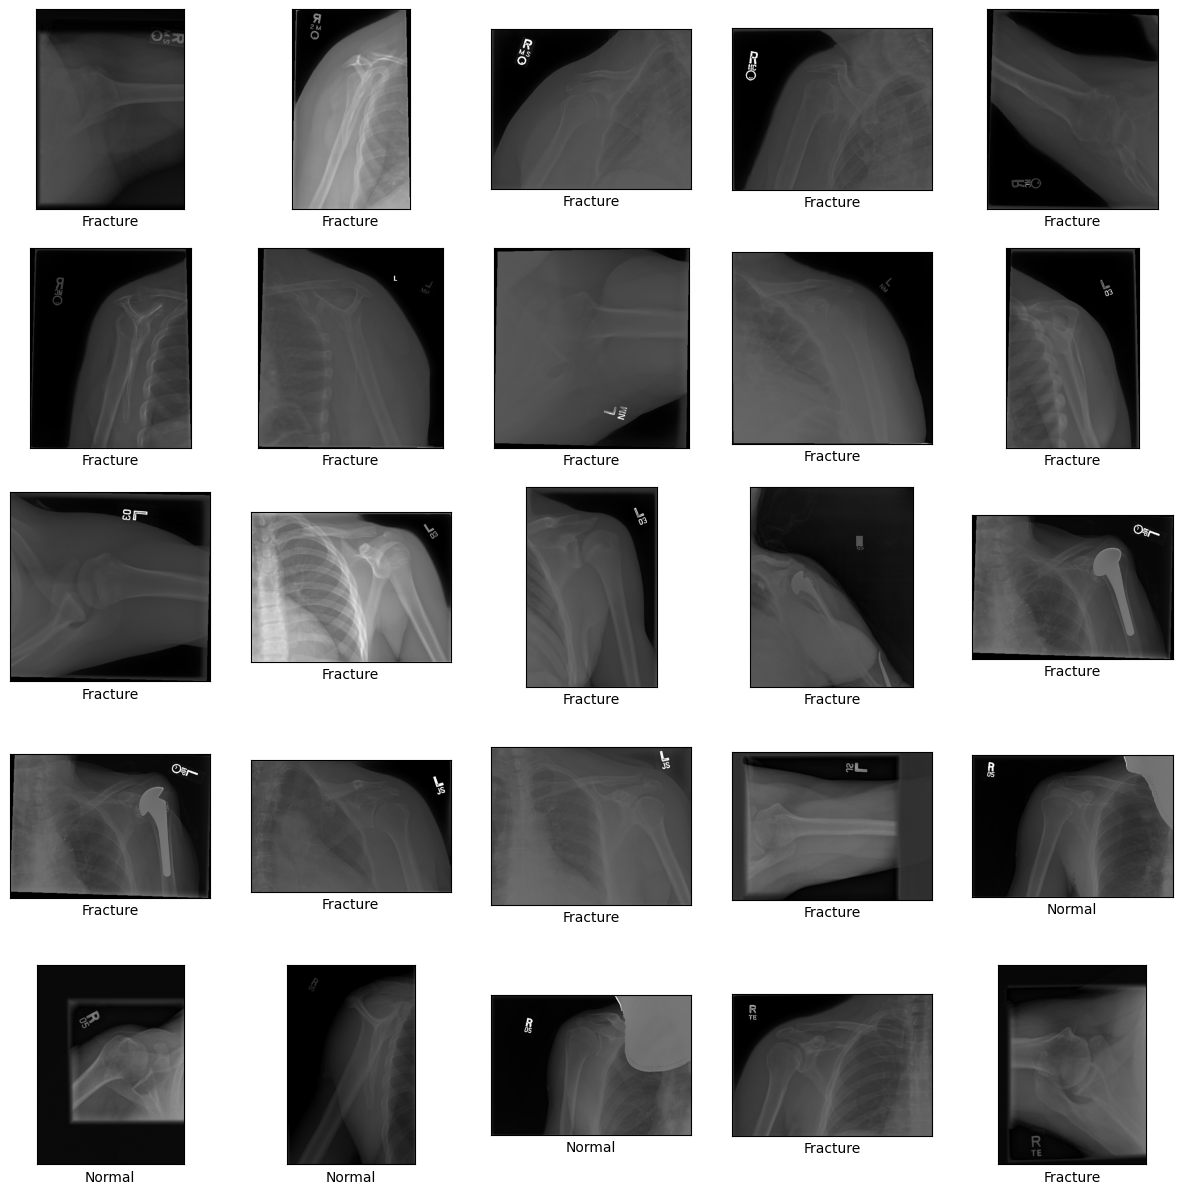

In [ ]:
plt.figure(figsize=(15,15))
for i in range(min(len(train_imgs), 25)):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    img = cv2.imread(train_imgs[i])
    plt.imshow(img, cmap='gray')
    plt.xlabel(train_labels[i])
plt.show()

## Check class distribution

In [ ]:
Fracture_count = 0
Normal_count = 0
for i in train_labels:
  if i == "Fracture":
    Fracture_count = Fracture_count + 1
  else:
    Normal_count = Normal_count + 1
print("Fracture class contains", Fracture_count, "images.")
print("Normal class contains", Normal_count, "images.")
print("Total:", Fracture_count+Normal_count)


Fracture class contains 14873 images.
Normal class contains 21935 images.
Total: 36808


## Image size

(406, 512, 3)


Text(0.5, 1.0, 'Normal')

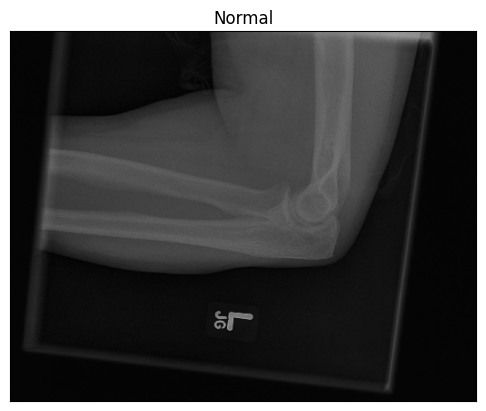

In [ ]:
num = random.randint(0,36808)
img = cv2.imread(train_imgs[num])
print(img.shape)
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title(train_labels[num])

## See pixels

In [ ]:
num = random.randint(0,36808)
img = cv2.imread(train_imgs[num], cv2.IMREAD_GRAYSCALE)
for row in img:
  for pixel in row:
    print(format(pixel),end = " ")
  print()

0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 73 73 72 72 73 73 69 69 68 68 

## Apply CHALE, Resize (224, 224), nomalize, reshape, batches(32*32), dataspilit into 3 parts (train, valdiation, test)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
def preprocess_xray_enhanced(img):
    # Step 1: uint8 convert
    if img.max() <= 1.0:
        img_uint8 = (img * 255).astype(np.uint8)
    else:
        img_uint8 = img.astype(np.uint8)

    # Step 2: Grayscale
    if img_uint8.ndim == 3:
        img_gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_uint8

    # Step 3: CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)

    img_blur = cv2.GaussianBlur(img_clahe, (0, 0), 3)
    img_sharp = cv2.addWeighted(img_clahe, 1.5, img_blur, -0.5, 0)

    sobelx = cv2.Sobel(img_sharp, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img_sharp, cv2.CV_64F, 0, 1, ksize=3)
    edges = np.sqrt(sobelx**2 + sobely**2)
    edges = cv2.normalize(
        edges, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    ch1 = img_sharp.astype('float32') / 255.0   # sharpened
    ch2 = img_clahe.astype('float32') / 255.0   # clahe
    ch3 = edges.astype('float32') / 255.0        # edges ✅

    img_processed = np.stack([ch1, ch2, ch3], axis=-1)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_processed = (img_processed - mean) / std

    return img_processed

train_data = pd.DataFrame({'filename': train_imgs, 'class': train_labels})
val_data   = pd.DataFrame({'filename': val_imgs,   'class': val_labels})
train_data['class'] = train_data['class'].map({'Fracture': '1', 'Normal': '0'})
val_data['class']   = val_data['class'].map({'Fracture': '1', 'Normal': '0'})

wrist_train_all = train_data[
    train_data['filename'].str.contains('WRIST')
].reset_index(drop=True)

wrist_val = val_data[
    val_data['filename'].str.contains('WRIST')
].reset_index(drop=True)

wrist_train_all['patient_id'] = wrist_train_all['filename'].str.extract(r'(patient\d+)')
wrist_val['patient_id']       = wrist_val['filename'].str.extract(r'(patient\d+)')

gss_wrist = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=123)
train_idx, test_idx = next(gss_wrist.split(
    wrist_train_all,
    groups=wrist_train_all['patient_id']
))

wrist_train = wrist_train_all.iloc[train_idx].reset_index(drop=True)
wrist_test  = wrist_train_all.iloc[test_idx].reset_index(drop=True)

train_patients = set(wrist_train['patient_id'])
test_patients  = set(wrist_test['patient_id'])
val_patients   = set(wrist_val['patient_id'])

print("=== WRIST DATASET ===")
print(f"Train images:   {len(wrist_train)}")
print(f"Val images:     {len(wrist_val)}")
print(f"Test images:    {len(wrist_test)}")
print(f"\nTrain patients: {len(train_patients)}")
print(f"Val patients:   {len(val_patients)}")
print(f"Test patients:  {len(test_patients)}")

print("\n=== LEAKAGE CHECK ===")
print(f"Train-Test overlap: {len(train_patients & test_patients)}")
print(f"Train-Val overlap:  {len(train_patients & val_patients)}")

print("\n=== CLASS DISTRIBUTION ===")
print("Train:")
print(wrist_train['class'].value_counts())
print("\nVal:")
print(wrist_val['class'].value_counts())
print("\nTest:")
print(wrist_test['class'].value_counts())

f_count = (wrist_train['class'] == '1').sum()
n_count = (wrist_train['class'] == '0').sum()
total   = f_count + n_count
class_weights_dict = {
    0: total / (2.0 * n_count),
    1: total / (2.0 * f_count)
}
print(f"\nFracture: {f_count}, Normal: {n_count}")
print(f"Class weights: {class_weights_dict}")

=== WRIST DATASET ===
Train images:   8307
Val images:     659
Test images:    1445

Train patients: 2776
Val patients:   207
Test patients:  491

=== LEAKAGE CHECK ===
Train-Test overlap: 0
Train-Val overlap:  0

=== CLASS DISTRIBUTION ===
Train:
class
0    4963
1    3344
Name: count, dtype: int64

Val:
class
0    364
1    295
Name: count, dtype: int64

Test:
class
0    802
1    643
Name: count, dtype: int64

Fracture: 3344, Normal: 4963
Class weights: {0: np.float64(0.8368930082611323), 1: np.float64(1.2420753588516746)}


## Compare normal, CHALE and Edge highlighted images

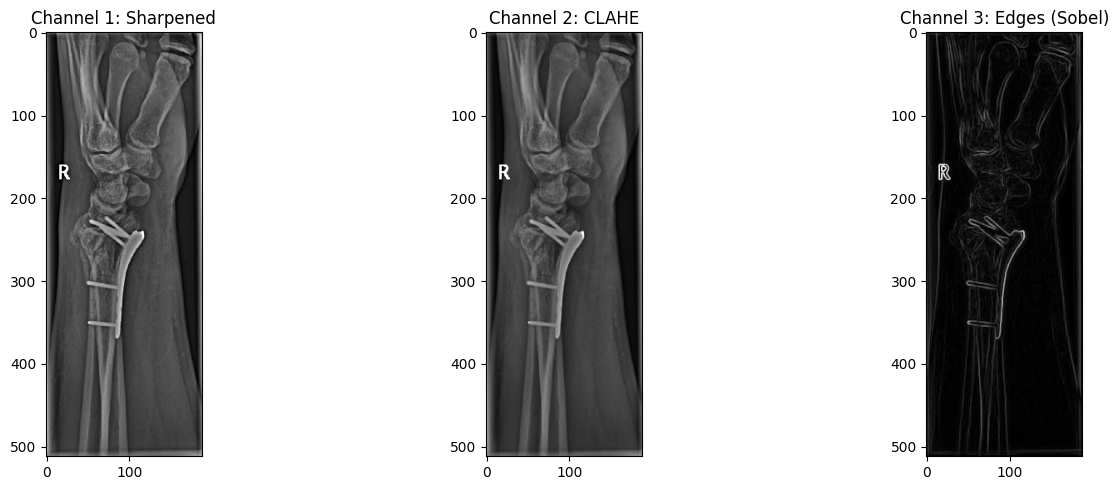

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Ek test image lo
img = cv2.imread(wrist_train['filename'][0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Preprocessing apply karo
processed = preprocess_xray_enhanced(img_rgb)

# Reverse normalization for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
display = processed * std + mean
display = np.clip(display, 0, 1)

# Plot karo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(display[:,:,0], cmap='gray')
axes[0].set_title('Channel 1: Sharpened')

axes[1].imshow(display[:,:,1], cmap='gray')
axes[1].set_title('Channel 2: CLAHE')

axes[2].imshow(display[:,:,2], cmap='gray')
axes[2].set_title('Channel 3: Edges (Sobel)')

plt.tight_layout()
plt.show()

## Data Generators

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Seprate the Fracture aur normal
wrist_fracture_df = wrist_train[wrist_train['class'] == '1'].reset_index(drop=True)
wrist_normal_df   = wrist_train[wrist_train['class'] == '0'].reset_index(drop=True)

wrist_fracture_df['label'] = 1.0
wrist_normal_df['label']   = 0.0

# Weights
w0 = class_weights_dict[0]
w1 = class_weights_dict[1]

print(f"Fracture images: {len(wrist_fracture_df)}")
print(f"Normal images:   {len(wrist_normal_df)}")
print(f"W0 (normal):     {w0:.4f}")
print(f"W1 (fracture):   {w1:.4f}")

# Augmentation
aug = dict(
    preprocessing_function=preprocess_xray_enhanced,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Fracture generator
wrist_fracture_gen = ImageDataGenerator(**aug).flow_from_dataframe(
    wrist_fracture_df,
    x_col='filename', y_col='label',
    target_size=(320,320), color_mode='rgb',
    batch_size=16, class_mode='raw', shuffle=True
)

# Normal generator
wrist_normal_gen = ImageDataGenerator(**aug).flow_from_dataframe(
    wrist_normal_df,
    x_col='filename', y_col='label',
    target_size=(320,320), color_mode='rgb',
    batch_size=16, class_mode='raw', shuffle=True
)

# Val generator
wrist_val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_xray_enhanced
).flow_from_dataframe(
    wrist_val,
    x_col='filename', y_col='class',
    target_size=(320,320), color_mode='rgb',
    batch_size=32, class_mode='binary', shuffle=False
)

# Test generator
wrist_test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_xray_enhanced
).flow_from_dataframe(
    wrist_test,
    x_col='filename', y_col='class',
    target_size=(320,320), color_mode='rgb',
    batch_size=32, class_mode='binary', shuffle=False
)

# Balanced generator
def balanced_generator(g1, g2):
    while True:
        X1, y1 = next(g1)
        X2, y2 = next(g2)
        X = np.concatenate([X1, X2])
        y = np.concatenate([y1, y2])
        sample_weights = np.where(y == 1, w1, w0)
        idx = np.random.permutation(len(X))
        yield X[idx], y[idx], sample_weights[idx]

wrist_gen_balanced = balanced_generator(
    wrist_fracture_gen,
    wrist_normal_gen
)
wrist_steps = min(
    len(wrist_fracture_gen),
    len(wrist_normal_gen)
) * 2

print(f"\nSteps per epoch: {wrist_steps}")

# Verify
Xb, yb, wb = next(wrist_gen_balanced)
print(f"Batch shape:     {Xb.shape}")
print(f"Fracture %:      {yb.mean()*100:.1f}%")
print(f"Sample weights:  {wb[:4]}")

Fracture images: 3344
Normal images:   4963
W0 (normal):     0.8369
W1 (fracture):   1.2421
Found 3344 validated image filenames.
Found 4963 validated image filenames.
Found 659 validated image filenames belonging to 2 classes.
Found 1445 validated image filenames belonging to 2 classes.

Steps per epoch: 418
Batch shape:     (32, 320, 320, 3)
Fracture %:      50.0%
Sample weights:  [0.83689301 0.83689301 1.24207536 0.83689301]


## Shapes of training, validation & testing batches




In [ ]:
X_train, y_train, w_train = next(wrist_gen_balanced)
print("Train batch shapes:", X_train.shape, y_train.shape)

X_val, y_val = next(wrist_val_gen)
print("Val batch shapes:", X_val.shape, y_val.shape)

X_test, y_test = next(wrist_test_gen)
print("Test batch shapes:", X_test.shape, y_test.shape)

# Verification: ek batch lo aur stats dekho
X_batch, y_batch, w_batch = next(wrist_gen_balanced)
print("Min pixel value:", X_batch.min())
print("Max pixel value:", X_batch.max())
print("Mean:", X_batch.mean())

Train batch shapes: (32, 320, 320, 3) (32,)
Val batch shapes: (32, 320, 320, 3) (32,)
Test batch shapes: (32, 320, 320, 3) (32,)
Min pixel value: -2.117904
Max pixel value: 2.64
Mean: -1.1280236


## See images from batches

{0: 'Normal', 1: 'Fracture'}


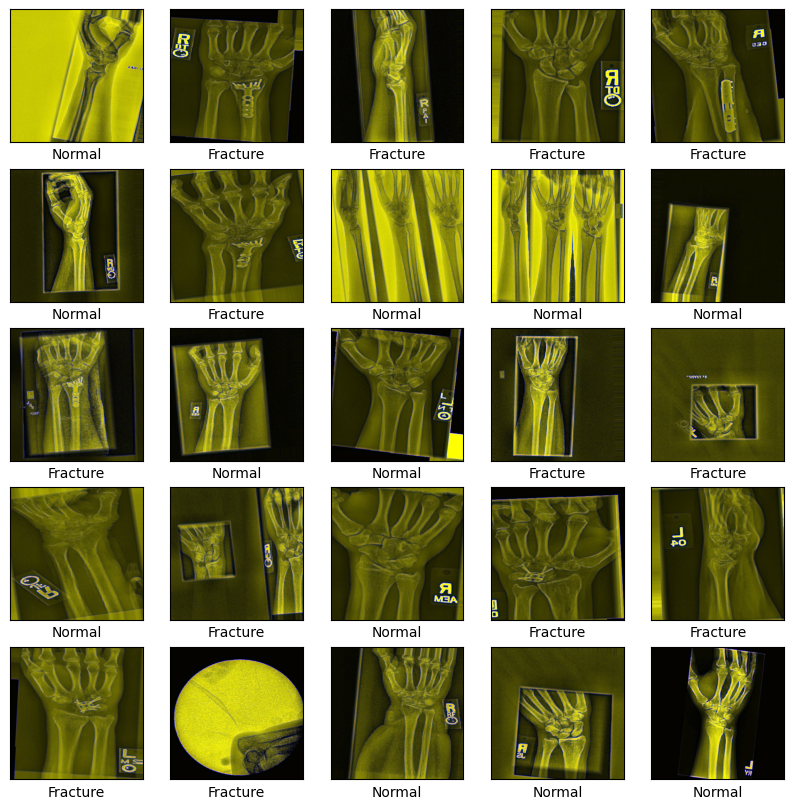

In [ ]:
class_names = {0: 'Normal', 1: 'Fracture'}
print(class_names)

plt.figure(figsize=(10,10))

# ImageNet params
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

for i in range(min(len(X_train), 25)):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    img = X_train[i]
#  Reverse normalization
    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    plt.xlabel(class_names[int(y_train[i])])

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    shared_1 = layers.Dense(channel // ratio, activation='relu', use_bias=False)
    shared_2 = layers.Dense(channel, use_bias=False)

    avg = layers.GlobalAveragePooling2D()(x)
    avg = layers.Reshape((1, 1, channel))(avg)
    avg = shared_1(avg)
    avg = shared_2(avg)

    max_ = layers.GlobalMaxPooling2D()(x)
    max_ = layers.Reshape((1, 1, channel))(max_)
    max_ = shared_1(max_)
    max_ = shared_2(max_)

    attention = layers.Add()([avg, max_])
    attention = layers.Activation('sigmoid')(attention)
    return layers.Multiply()([x, attention])

class SpatialAttention(layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = layers.Conv2D(
            1, kernel_size,
            padding='same',
            activation='sigmoid',
            use_bias=False,
            name='spatial_attention_map'
        )

    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_ = tf.reduce_max(x, axis=-1, keepdims=True)
        concat = layers.Concatenate(axis=-1)([avg, max_])
        attention = self.conv(concat)
        return layers.Multiply()([x, attention]), attention

    def get_config(self):
        config = super().get_config()
        config.update({'kernel_size': self.kernel_size})
        return config

def cbam_block(x, ratio=8, kernel_size=7):
    x = channel_attention(x, ratio)
    spatial_layer = SpatialAttention(kernel_size=kernel_size)
    x, attention_map = spatial_layer(x)
    return x, attention_map


## Model building => DenseNet121(Transfer learning)

In [ ]:
def build_wrist_model():
    base_model = tf.keras.applications.DenseNet121(
        input_shape=(320, 320, 3),
        include_top=False,
        weights='imagenet'
    )

    for layer in base_model.layers:
        layer.trainable = False
    for layer in base_model.layers[-100:]:
        if not isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = True

    inputs = tf.keras.Input(shape=(320, 320, 3))
    x = base_model(inputs)
    x, attention_map = cbam_block(x, ratio=8, kernel_size=7)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='gelu',
                     kernel_regularizer=l2(1e-3))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='gelu',
                     kernel_regularizer=l2(1e-3))(x)
    outputs = layers.Dense(1, activation='sigmoid',
                           name='prediction')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

# wrist_model = build_wrist_model()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Compile the model

In [ ]:
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow(1 - p_t, gamma) * bce
    return loss

wrist_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
    loss=focal_loss(gamma=2, alpha=0.60),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

NameError: name 'wrist_model' is not defined

## Summary

In [ ]:
wrist_model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 10, 10,    │  7,037,504 │ input_layer_10[0… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1,      │          0 │ global_max_pooli… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 1, 128) │    131,072 │ reshape_2[0][0],  │
│                     │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1, 1,      │    131,072 │ dense_5[0][0],    │
│                     │ 1024)             │            │ dense_5[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 1,      │          0 │ dense_6[0][0],    │
│                     │ 1024)             │            │ dense_6[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1, 1,      │          0 │ add_1[0][0]       │
│ (Activation)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 10, 10,    │          0 │ densenet121[0][0… │
│ (Multiply)          │ 1024)             │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 10, 10, 1) │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 10, 10, 1) │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 10, 10, 2) │          0 │ lambda[0][0],     │
│ (Concatenate)       │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_attention_… │ (None, 10, 10, 1) │         98 │ concatenate[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 10, 10,    │          0 │ multiply_1[0][0], │
│ (Multiply)          │ 1024)             │            │ spatial_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ multiply_2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,443,363 (28.39 MB)

 Trainable params: 2,324,835 (8.87 MB)

 Non-trainable params: 5,118,528 (19.53 MB)

## Mount the drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Create folder if does not exit

In [ ]:
import os
# Apni Drive mein folder ka naam dekho
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for d in dirs:
        print(os.path.join(root, d))

/content/drive/MyDrive/Deep Learning Practice
/content/drive/MyDrive/Colab Notebooks


## ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc', mode='max',
    factor=0.4, patience=2,
    min_lr=1e-7, verbose=1
)

early_stop = EarlyStopping(
    monitor='val_auc', mode='max',
    patience=5,
    restore_best_weights=True, verbose=1
)

best_checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_wrist_model.keras',
    monitor='val_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Har epoch save
all_checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/wrist_model_epoch_{epoch:02d}.keras',
    save_best_only=False,
    verbose=0
)

In [ ]:
print("1. CLASS WEIGHTS")
print(class_weights_dict)

print("\n2. GENERATOR CLASS MAPPING")
print("train_gen: {'0': 0, '1': 1}")
print("val_gen:  ", wrist_val_gen.class_indices)
print("test_gen: ", wrist_test_gen.class_indices)

print("\n3. GENERATOR SIZES")
# For train_gen_balanced, use the pre-calculated steps_per_epoch.
print(f"train_gen steps per epoch: {wrist_steps}")
print(f"val_gen   steps per epoch: {len(wrist_val_gen)}")

print("\n4. MODEL INPUT/OUTPUT")
print("Input shape: ", wrist_model.input_shape)
print("Output shape:", wrist_model.output_shape)

print("\n5. OPTIMIZER & LR")
print("LR:", wrist_model.optimizer.learning_rate.numpy())

print("\n6. TRAINABLE LAYERS COUNT")
trainable = sum(1 for l in wrist_model.layers[1].layers if l.trainable)
frozen     = sum(1 for l in wrist_model.layers[1].layers if not l.trainable)
print(f"Trainable: {trainable}, Frozen: {frozen}")

print("\n7. PIXEL STATS FROM TRAIN BATCH")
Xb, yb, wb = next(wrist_gen_balanced) # Unpack all three return values (X, y, sample_weights)
print(f"Min: {Xb.min():.3f}, Max: {Xb.max():.3f}, Mean: {Xb.mean():.3f}")
print(f"Batch class balance: {yb.mean()*100:.1f}% fracture")

print("ALL CHECKS DONE — ready to train")

1. CLASS WEIGHTS
{0: np.float64(0.8368930082611323), 1: np.float64(1.2420753588516746)}

2. GENERATOR CLASS MAPPING
train_gen: {'0': 0, '1': 1}
val_gen:   {'0': 0, '1': 1}
test_gen:  {'0': 0, '1': 1}

3. GENERATOR SIZES
train_gen steps per epoch: 418
val_gen   steps per epoch: 21

4. MODEL INPUT/OUTPUT
Input shape:  (None, 320, 320, 3)
Output shape: (None, 1)

5. OPTIMIZER & LR
LR: 3e-06

6. TRAINABLE LAYERS COUNT
Trainable: 71, Frozen: 356

7. PIXEL STATS FROM TRAIN BATCH
Min: -2.118, Max: 2.640, Mean: -1.144
Batch class balance: 50.0% fracture
ALL CHECKS DONE — ready to train


In [ ]:
loaded = load_wrist_model('/content/drive/MyDrive/wrist_model_epoch_16.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'spatial_attention_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model loaded!


## Training

In [ ]:
history = loaded.fit(
    wrist_gen_balanced,
    steps_per_epoch=wrist_steps,
    validation_data=wrist_val_gen,
    epochs=50,
    callbacks=[reduce_lr, early_stop, best_checkpoint, all_checkpoint]
)

Epoch 1/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8134 - auc: 0.8877 - loss: 0.2686 - precision: 0.8288 - recall: 0.7901
Epoch 1: val_auc improved from None to 0.87996, saving model to /content/drive/MyDrive/best_wrist_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_wrist_model.keras
418/418 ━━━━━━━━━━━━━━━━━━━━ 620s 1s/step - accuracy: 0.8123 - auc: 0.8885 - loss: 0.2675 - precision: 0.8270 - recall: 0.7904 - val_accuracy: 0.8134 - val_auc: 0.8800 - val_loss: 0.2726 - val_precision: 0.9095 - val_recall: 0.6475 - learning_rate: 3.0000e-06
Epoch 2/50
418/418 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8143 - auc: 0.8920 - loss: 0.2636 - precision: 0.8318 - recall: 0.7885
Epoch 2: val_auc did not improve from 0.87996
418/418 ━━━━━━━━━━━━━━━━━━━━ 520s 1s/step - accuracy: 0.8145 - auc: 0.8918 - loss: 0.2628 - precision: 0.8303 - recall: 0.7910 - val_accuracy: 0.8164 - val_auc: 0.8799 - val_loss: 0.2700 - val_precision: 0.9183 - val_recall: 0.6475

## Wrist Best Model

In [ ]:
wrist_model.save('/content/test_model.keras')

## Load Model

In [ ]:
# def save_wrist_model(model, path):
#     model.save(path)
#     print(f"Saved: {path}")


def load_wrist_model(path):
    custom_objects = {
        'SpatialAttention': SpatialAttention,
        'loss': focal_loss(gamma=2, alpha=0.60)
    }
    model = tf.keras.models.load_model(
        path,
        custom_objects=custom_objects
    )
    print("Model loaded!")
    return model

# Evaluation

## Find best best recall, Precision and F1

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

wrist_val_gen.reset()
all_probs = []
all_true = []

for _ in range(len(wrist_val_gen)):
    Xb, yb = next(wrist_val_gen)
    probs = loaded.predict(Xb, verbose=0)
    all_probs.extend(probs.flatten())
    all_true.extend(yb)

all_probs = np.array(all_probs)
all_true = np.array(all_true)

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 45)

for t in np.arange(0.2, 0.7, 0.05):
    preds = (all_probs > t).astype(int)
    p = precision_score(all_true, preds)
    r = recall_score(all_true, preds)
    f1 = f1_score(all_true, preds)
    print(f"{t:>10.2f} {p:>10.3f} {r:>10.3f} {f1:>10.3f}")

 Threshold  Precision     Recall         F1
---------------------------------------------
      0.20      0.652      0.864      0.743
      0.25      0.722      0.827      0.771
      0.30      0.802      0.783      0.792
      0.35      0.846      0.742      0.791
      0.40      0.873      0.702      0.778
      0.45      0.891      0.664      0.761
      0.50      0.927      0.644      0.760
      0.55      0.943      0.620      0.748
      0.60      0.951      0.593      0.731
      0.65      0.960      0.563      0.709


## Accuracy and confusion matrix (Threshold = 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

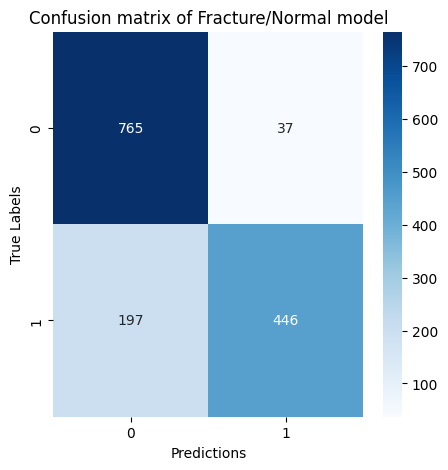

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

true_classes_labels = wrist_test_gen.classes

wrist_test_gen.reset()

all_predictions = []
all_true_labels = []

for _ in range(len(wrist_test_gen)):
    X_batch, y_batch = next(wrist_test_gen)

    batch_predictions = loaded.predict(X_batch)
    all_predictions.extend(batch_predictions.flatten())
    all_true_labels.extend(y_batch)

predictions = np.array(all_predictions)
true_classes_labels = np.array(all_true_labels)

predicted_classes = (predictions > 0.5).astype(int)

# Verify lengths before calculating metrics
print(f"Length of true_classes_labels: {len(true_classes_labels)}")
print(f"Length of predicted_classes: {len(predicted_classes)}")

# Calculate metrics
acc = accuracy_score(true_classes_labels, predicted_classes)
cm = confusion_matrix(true_classes_labels, predicted_classes)

print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)

plt.figure(figsize = (5,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("Predictions")
plt.ylabel("True Labels")
plt.title("Confusion matrix of Fracture/Normal model")
plt.show()

## Accuracy and Confusion matrix (Threshold = 0.35)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

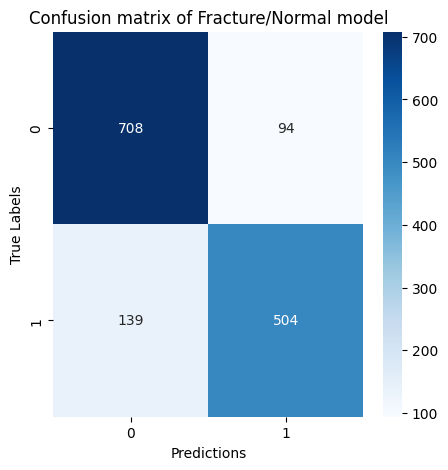

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

true_classes_labels = wrist_test_gen.classes

wrist_test_gen.reset()

all_predictions = []
all_true_labels = []

# Iterate through the test generator to get batches and make predictions
for _ in range(len(wrist_test_gen)):
    X_batch, y_batch = next(wrist_test_gen)
    batch_predictions = loaded.predict(X_batch)
    all_predictions.extend(batch_predictions.flatten())
    all_true_labels.extend(y_batch)

# Convert to numpy arrays
predictions = np.array(all_predictions)
true_classes_labels = np.array(all_true_labels)

predicted_classes = (predictions > 0.35).astype(int)

# Verify lengths before calculating metrics
print(f"Length of true_classes_labels: {len(true_classes_labels)}")
print(f"Length of predicted_classes: {len(predicted_classes)}")

# Calculate metrics
acc = accuracy_score(true_classes_labels, predicted_classes)
cm = confusion_matrix(true_classes_labels, predicted_classes)

print("Test Accuracy:", acc)
print("Confusion Matrix:\n", cm)

plt.figure(figsize = (5,5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel("Predictions")
plt.ylabel("True Labels")
plt.title("Confusion matrix of Fracture/Normal model")
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def explainable_prediction(img_path, model, threshold=0.35):

    # Original model's input
    input_tensor = model.input

    # Get the attention map tensor from the SpatialAttention layer's second output
    # The SpatialAttention layer itself is named 'spatial_attention_1'
    # Its `call` method returns two outputs, the second one (index 1) is the attention map.
    attention_map_tensor = model.get_layer('spatial_attention_1').output[1]

    # Create a new model that outputs both the final prediction and the attention map
    attention_model = tf.keras.Model(
        inputs=input_tensor,
        outputs=[
            model.output, # The original prediction output
            attention_map_tensor # The attention map output
        ]
    )

    # Image load + preprocess
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (320, 320))
    img_processed = preprocess_xray_enhanced(img_resized)
    img_array = np.expand_dims(img_processed, axis=0)

    # Prediction + attention
    pred_output, attention_output = attention_model.predict(
        img_array, verbose=0
    )
    pred_value = float(pred_output[0][0])
    label = "Fracture" if pred_value > threshold else "Normal"
    confidence = pred_value if pred_value > threshold else 1 - pred_value

    # Attention map process
    att_map = attention_output[0, :, :, 0] # Extract the attention map
    att_map = cv2.resize(att_map, (320, 320))
    att_map = (att_map - att_map.min()) / (
        att_map.max() - att_map.min() + 1e-8
    )

    # Heatmap
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * att_map), cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(
        heatmap_colored, cv2.COLOR_BGR2RGB
    )

    # Overlay
    superimposed = cv2.addWeighted(
        img_resized, 0.6,
        heatmap_colored, 0.4, 0
    )

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_resized)
    axes[0].set_title('Original X-ray', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(att_map, cmap='jet')
    axes[1].set_title(
        'Attention Map',
        fontsize=14
    )
    axes[1].axis('off')

    axes[2].imshow(superimposed)
    axes[2].set_title(
        f'Prediction: {label}\n'
        f'Confidence: {confidence*100:.1f}%',
        fontsize=14,
        color='red' if label == 'Fracture' else 'green'
    )
    axes[2].axis('off')

    plt.suptitle(
        f'Wrist Fracture Detection — {label}',
        fontsize=16, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print(f"\nPrediction:  {label}")
    print(f"Confidence:  {confidence*100:.1f}%")
    print(f"Raw score:   {pred_value:.4f}")

    return label, confidence


In [ ]:
# Fracture images
print("=" * 50)
print("FRACTURE IMAGES")
print("=" * 50)
for i in range(3):
    img_path = wrist_test[
        wrist_test['class'] == '1'
    ]['filename'].iloc[i]
    explainable_prediction(img_path, loaded)

# Normal images
print("=" * 50)
print("NORMAL IMAGES")
print("=" * 50)
for i in range(3):
    img_path = wrist_test[
        wrist_test['class'] == '0'
    ]['filename'].iloc[i]
    explainable_prediction(img_path, loaded)

## Plot training and validation(accuracy & loss)

In [ ]:
import matplotlib.pyplot as plt

# Get training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()